In [61]:
#import libraries
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
import seaborn as  sns
import sqlite3

In [62]:
#1.import database/data

In [63]:
##connecting python to sqlite
conn=sqlite3.connect('customer_churn.db')
sql_query='''
       SELECT name
       from sqlite_master
       where type='table'
'''

tables=pd.read_sql(sql_query,conn)

## create dataframe
for table_name in tables['name']:
    df=pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"Created dataframe:df_{table_name}")
conn.close()    

Created dataframe:df_db_customer
Created dataframe:df_db_subscription
Created dataframe:df_db_support


In [64]:
##Print table names and column names
conn=sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name:{table_name}")
    #get column information
    columns_query=f"PRAGMA table_info({table_name});"
    columns=pd.read_sql(columns_query,conn)
    print("Columns:")
    print(columns['name'].tolist())
## close connection
conn.close()


Table Name:db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name:db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name:db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [65]:
##2. Data Cleaning

In [66]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [67]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [68]:
## data cleaning for db_customer table
##a. drop columns interests,pincode
##b. rename column name to customer_name
##c. change data type of dob
##d. data standardisation-gender
##e. fix missing values in country

In [69]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [70]:
## rename column name to customer_name
df_db_customer.rename(columns={'name':'customer_name'},inplace=True)

In [71]:
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [72]:
df_db_customer.drop(df_db_customer.columns[-2:],axis=1,inplace=True)
##df_db_customer.columns[-2:]
##df_db_customer.drop(columns in ['interests','pincode'],inplace=True)

In [73]:
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00


In [74]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer_name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


In [75]:
## change data type of dob
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

In [76]:
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05


In [77]:
## data standardization-gender
df_db_customer['gender'].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [78]:
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})

In [79]:
## fix missing values in country
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [80]:
##country-state unique value pair
state_country_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [81]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [82]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [83]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [84]:
date_col=['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [85]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [86]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [87]:
## drop column name col_1, comment
df_db_support.drop(columns=['col_1','comment'],inplace=True)

In [88]:
##change the complaint_date data type object to date
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])
##df_db_support.info()

In [89]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [90]:
## 3. feature engineering and data analysis

In [91]:
## create a new column(churn flag) using existiong column (cancellation date)
df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [92]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [93]:
## first fix support table duplicates then merge
df=(df_db_subscription
           .merge(df_db_customer ,on='customerid',how='left')
           .merge(df_db_support ,on='customerid',how='left'))

In [94]:
df_db_subscription.shape

(21, 12)

In [95]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [96]:
df_db_customer.shape

(21, 6)

In [97]:
df_db_support.shape

(9, 4)

In [98]:
df_db_subscription.shape

(21, 12)

In [99]:
df_db_subscription['customerid'].nunique()

21

In [100]:
df_db_customer['customerid'].nunique()

21

In [101]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [102]:
df_db_support['customerid'].size

9

In [103]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [104]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [105]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [106]:
df_db_customer.shape

(21, 6)

In [107]:
##merge df
df_merge=(df_db_subscription
           .merge(df_db_customer,on='customerid',how='left')
            .merge(df_db_support,on='customerid',how='left'))

In [108]:
df_merge.shape

(21, 21)

In [109]:
df_merge.to_csv('exported_churn_data.csv',index=False)

In [110]:
##Data Analysis

In [111]:
## 1. Churn analysis

In [112]:
df_merge.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [113]:
# Churn rate for 21 customers
churn_rate=df_merge['churn_flag'].mean()*100
print("Churn Rate=",round(churn_rate,2),"%")

Churn Rate= 28.57 %


In [114]:
## 2. Retention rate
Retention_rate=100-churn_rate
print("Retention Rate=",round(Retention_rate,2),"%")

Retention Rate= 71.43 %


In [115]:
## 3. churn by plan type
churn_by_plan=(df_merge.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_%'))
print(churn_by_plan)

  plan_type  churn_rate_%
0     Basic         60.00
1   Premium         14.29
2  Standard         22.22


In [116]:
## maximum churn is happening in Basic plan

In [117]:
##4(a) churn by state + sum(revenue) and count(users)
churn_by_state=(df_merge.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_%'))
print(churn_by_state)

           state  churn_rate_%
0          Delhi         25.00
1      Karnataka        100.00
2      Kathmandu          0.00
3    Maharashtra          0.00
4      Meghalaya         66.67
5       Nagaland          0.00
6      Rajasthan          0.00
7      Telangana         50.00
8  Uttar Pradesh          0.00


In [118]:
## 4(b) churn by subscription type  + sum(revenue) and count(users)
churn_by_subscription=(df_merge.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_%'))
print(churn_by_subscription)

  subscription_type  churn_rate_%
0           Organic          0.00
1              Paid         16.67
2          Refferal         83.33


In [119]:
## 5. ARPU-Average Revenue Per User
arpu=df['monthly_charges'].mean()
print("ARPU=",round(arpu,2),'%')

ARPU= 18.51 %


In [120]:
## calculate customers age

In [121]:
## 6.Avg customer tenure
##count of days users has used our services: 
today=pd.Timestamp.today()
df_merge['tenure_days']=np.where(
       df_merge['cancellation_date'].notna(),
      (df_merge['cancellation_date']-df_merge['subscription_start_date']).dt.days,
      (today-df_merge['subscription_start_date']).dt.days
)
avg_tenure=df_merge['tenure_days'].mean()
print("Avg Tenure(Days)=",round(avg_tenure,0))

Avg Tenure(Days)= 1537.0


In [122]:
#7.Revenue At Risk - Revenue lost from churned users
revenue_at_risk=df_merge.loc[df_merge['churn_flag']==1,'monthly_charges'].sum()
print("Revenue At Risk(Rs.'K')=",revenue_at_risk)

Revenue At Risk(Rs.'K')= 73.94


In [123]:
## 8. Escalation Rate
escalation_rate=(df_merge['escalations']=='Y').mean()*100
print("Escalation rate=",round(escalation_rate,2),"%")

Escalation rate= 19.05 %


In [124]:
# 9. avg complaint rate per user
avg_complaints=df_merge['complaint_count'].sum()/df_merge['customerid'].nunique()
print("Avg Complaints Per User=",round(avg_complaints,2),"%")

Avg Complaints Per User= 0.43 %


In [126]:
# 10. Correlation Escalation vs churn
corr_df=df_merge[['customerid','escalations','churn_flag']].dropna()
df_merge['escalations']=np.where(df_merge['escalations']=='Y',1,0)  # encoding str to int 
correlation=corr_df['escalations'].corr(df_merge['churn_flag'])

print("Corelation between churn vs escalations=",round(correlation,2))

Corelation between churn vs escalations= 0.77


In [127]:
# 11. churn risk- create a column using existing column
conditions=[
         (df_merge['churn_score']<50),
         (df_merge['churn_score']>=50) & (df_merge['churn_score']<70),
         (df_merge['churn_score']>=70)]
choices=['low','med','high']
df_merge['churn_risk']=np.select(conditions,choices,default='unknown')

In [128]:
df_merge.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,2007.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,0,10.0,2.0,1501.0,high


In [129]:
## 4. Visualizing using matplotlib

In [130]:
df_visual=df_merge.copy()

In [131]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [132]:
# 4.1 monthly churn trend(Time Series KPI)

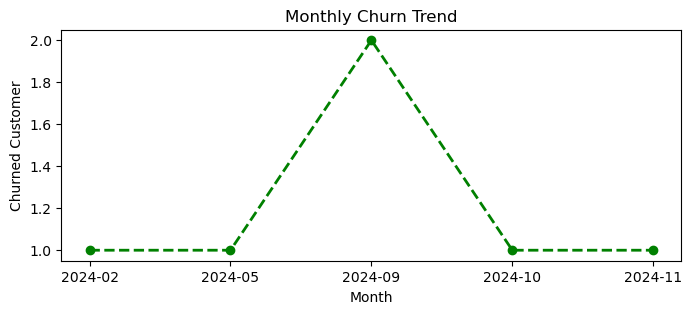

In [133]:
df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')
churn_trend=df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str),churn_trend.values,color='green',marker='o',linestyle='dashed',linewidth=2)
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customer')
plt.show()


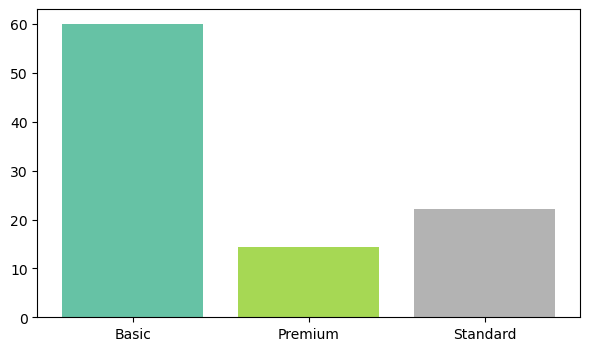

In [134]:
# 4.2 Churn By Plan Type
churn_plan=df_visual.groupby('plan_type')['churn_flag'].mean()*100
plt.figure(figsize=(7,4))
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.bar(churn_plan.index,churn_plan.values,color=colors)
plt.show()


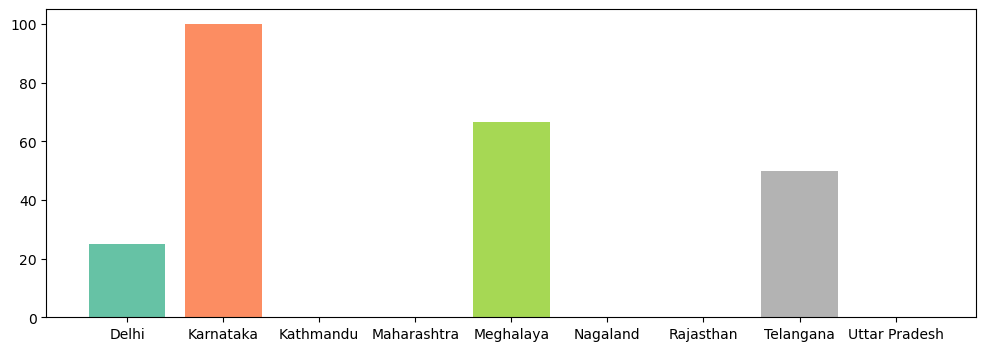

In [135]:
# 4.3 Churn By States
churn_state=df_visual.groupby('state')['churn_flag'].mean()*100
plt.figure(figsize=(12,4))
colors=plt.cm.Set2(np.linspace(0,1,len(churn_state)))
plt.bar(churn_state.index,churn_state.values,color=colors)
plt.show()


In [136]:
# visualization using seaborn
# Heatmap (correlation mark)



In [137]:
##convert str to numeric
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [138]:
df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,0
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,0


In [139]:
import warnings
warnings.filterwarnings("ignore")

In [140]:
# incorrect method of encoding- as numbers are not assigned based on priorities
df_encoded=df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]
categorical_cols=['plan_type','contract_type','churn_risk']
for col in categorical_cols:
    df_encoded[col]=df_encoded[col].astype('category').cat.codes

In [141]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,0
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,0


<Axes: >

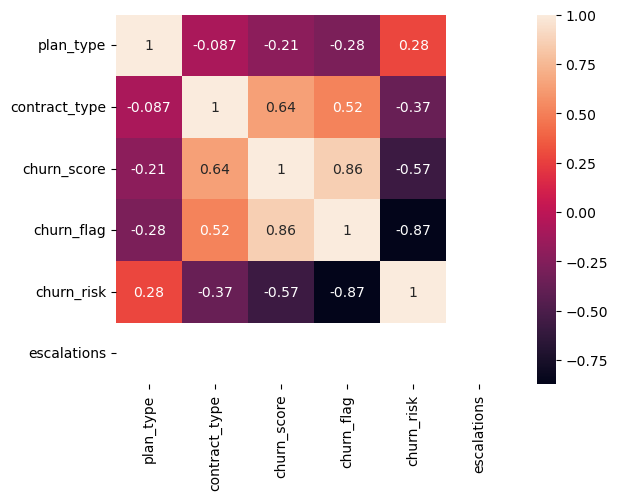

In [142]:
sns.heatmap(df_encoded.corr(),annot=True)

In [143]:
df_visual['churn_risk'].unique()

array(['low', 'high', 'med'], dtype=object)

In [144]:
# correct method of encoding- as numbers are not assigned based on priorities
df_encoded=df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']]
order_mappings={
    'plan_type':['Basic','Standard','Premium'],
    'contract_type':['Monthly','Annual'],
    'churn_risk':['low','med','high']
}
for col,order in order_mappings.items():
    df_encoded[col]=pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes

In [145]:
df_visual[['plan_type','contract_type','churn_score','churn_flag','churn_risk','escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,0
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,0


In [146]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,0
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,0


<Axes: >

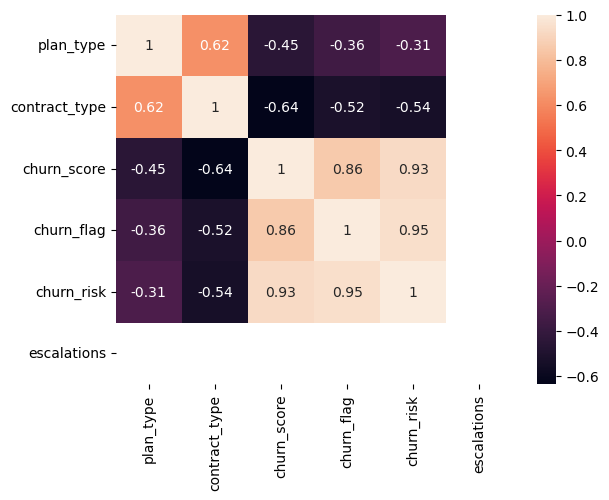

In [147]:
# heatmap(correlation matrix)
sns.heatmap(df_encoded.corr(),annot=True)

In [148]:
df_merge.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

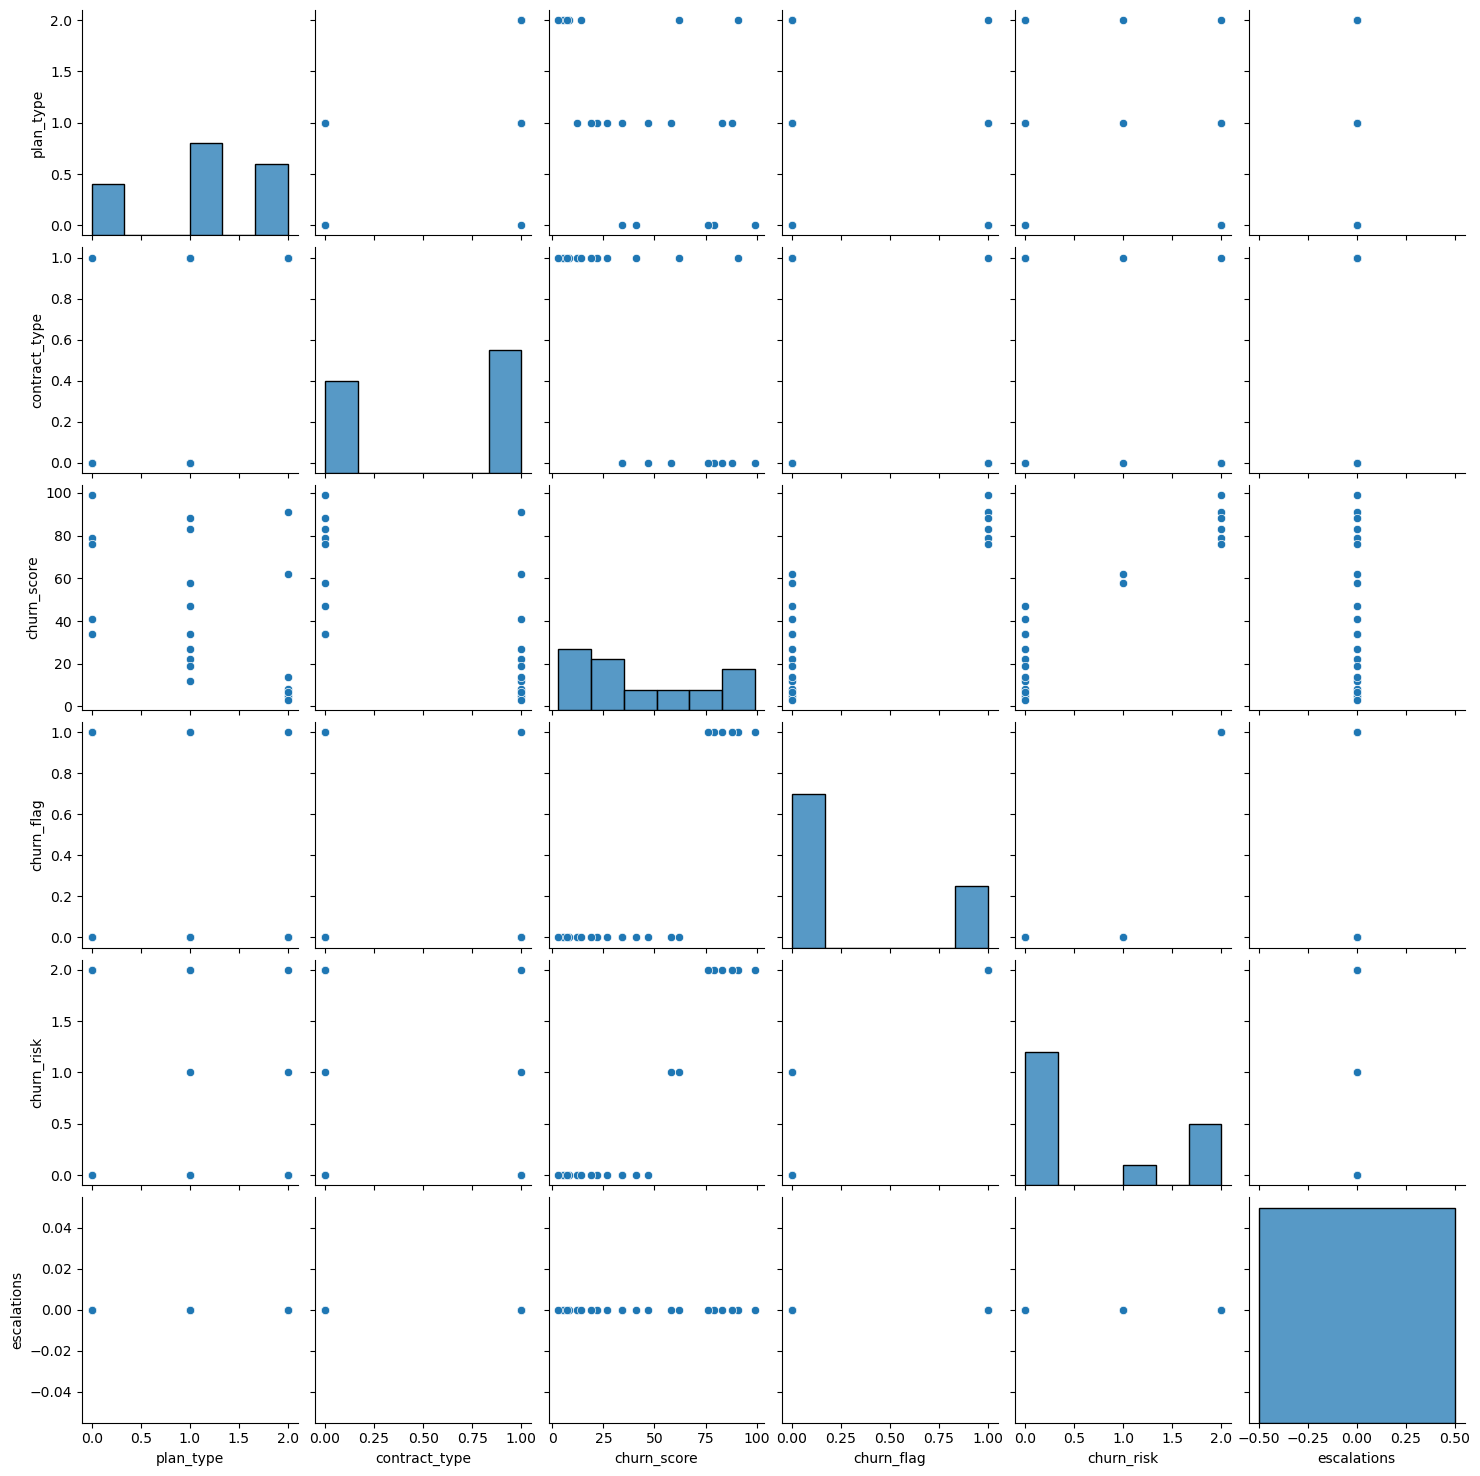

In [149]:
# pairplot-relationship in a dataset
sns.pairplot(df_encoded)

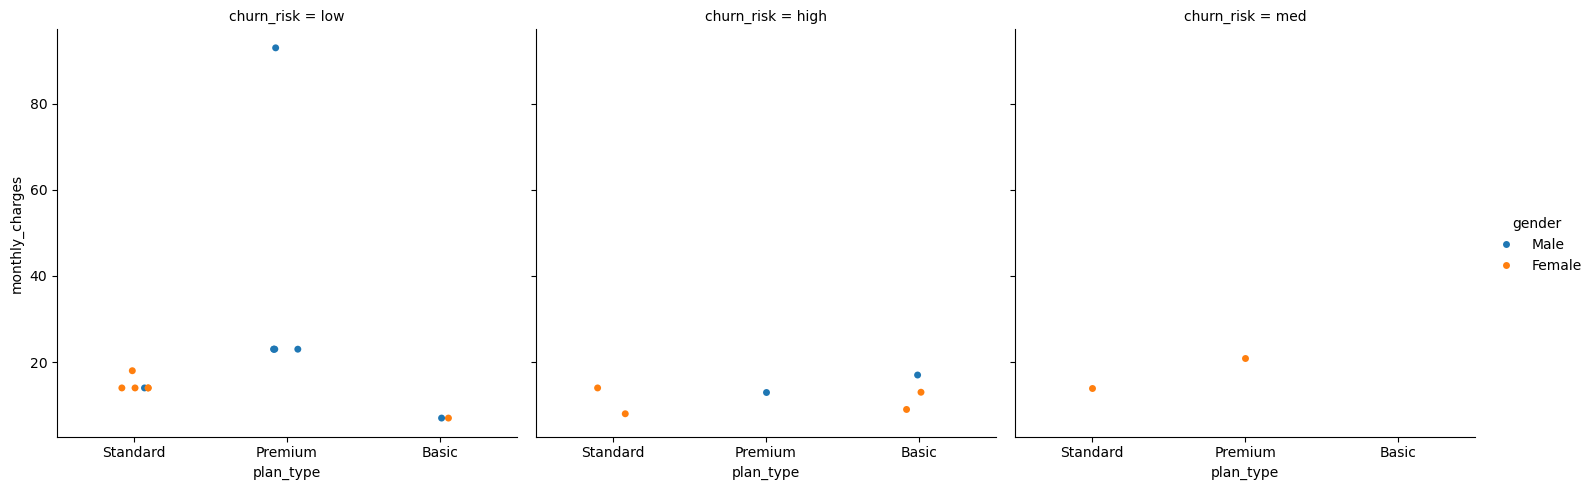

In [150]:
# catplot/facegrid plot- multi-dim comparision
sns.catplot(data=df_visual,
            x='plan_type',
            y='monthly_charges',
            hue='gender',
            col='churn_risk')
            
            

In [151]:
# Pivit Table
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['churn_flag','monthly_charges','customerid'],
    
    aggfunc={
        'churn_flag':'mean',
    'monthly_charges':'sum',
    'customerid':'nunique'
}).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


In [98]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')